In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

In [3]:
class Patch_MLP_ZEUS(nn.Module):
  def __init__(self, patch_size = 200, stride_size = 200, num_patches = 10, emmbedding_dim = 256):
    super(Patch_MLP_ZEUS, self).__init__()
    self.patch_size = patch_size
    self.stride_size = stride_size
    self.num_patches = num_patches
    self.emmbedding_dim = emmbedding_dim

    #Linar Embbeding Layer 
    self.emmbedding = nn.Linear(self.patch_size*2, self.emmbedding_dim)

    #Intra-Patch Mixing Layer
    self.intra_patch_mlp = nn.Sequential(
        nn.Linear(self.emmbedding_dim, self.emmbedding_dim),
        nn.GELU(),
        nn.Dropout(0.1),
        nn.Linear(self.emmbedding_dim, self.emmbedding_dim)
        )
    
    #Inter-Patch Mixing Layer
    self.inter_patch_mlp = nn.Sequential(
      nn.Linear(self.num_patches, self.num_patches),
      nn.GELU(),
      nn.Dropout(0.1),
      nn.Linear(self.num_patches, self.num_patches)
    )

    #Flatten
    self.flatten = nn.Flatten()
    self.output_layer = nn.Linear(self.num_patches*self.emmbedding_dim,2)
  def forward(self, x):
    batch_size = x.size(0)

    patches = []
    for i in range(self.num_patches):
        start_idx = i*self.stride_size
        end_idx = start_idx + self.patch_size
        patch = x[:, start_idx:end_idx, :].reshape(batch_size, -1)
        patches.append(patch)

    x = torch.stack(patches, dim=1)
    x = self.emmbedding(x)

    x = x + self.intra_patch_mlp(x)
    x = x.permute(0, 2, 1)

    x = x + self.inter_patch_mlp(x)
    x = x.permute(0, 2, 1)

    x = self.flatten(x)
    predicted_pos = self.output_layer(x)
    return predicted_pos


In [4]:
from torch.utils.data import Dataset, DataLoader

class ZEUS_Dataset(Dataset):
    def __init__(self, csv_file, window_size, split='train', train_ratio=0.8):
        df = pd.read_csv(csv_file)
        coords = df[['x', 'y']].values
        
        # 1. Store the ENTIRE array so it retains its full length (e.g., 27244)
        self.raw_data = coords
        self.window_size = window_size
        self.split = split
        
        # 2. Calculate the split point based on total available sliding windows
        self.total_windows = len(self.raw_data) - self.window_size
        self.split_index = int(self.total_windows * train_ratio)
        
        # 3. Calculate scaling factors using ONLY the training window data to prevent leakage
        train_slice = self.raw_data[:self.split_index + self.window_size]
        self.mean = train_slice.mean(axis=0)
        self.std = train_slice.std(axis=0)
        
        # 4. Standardize the entire array at once
        scaled_coords = (self.raw_data - self.mean) / self.std
        self.data = torch.tensor(scaled_coords, dtype=torch.float32)

    def __len__(self):
        # Return only the number of windows allocated to this specific split
        if self.split == 'train':
            return self.split_index
        else:
            return self.total_windows - self.split_index

    def __getitem__(self, idx):
        # If it's the test split, shift the pointer past the training window section
        if self.split != 'train':
            idx += self.split_index
            
        # These lookups will now work perfectly because self.data contains the full timeline length
        x_history = self.data[idx : idx + self.window_size]
        y_target = self.data[idx + self.window_size]

        return x_history, y_target
        

In [5]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, save_path='patch_mlp_zeus.pth'):
        """
        patience: How many epochs to wait after the test loss stops improving before stopping.
        min_delta: Minimum change in test loss to qualify as an improvement.
        save_path: File name where the best model weights should be saved.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, test_loss, model):
        if self.best_loss is None:
            self.best_loss = test_loss
            self.save_checkpoint(model)
        elif test_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            print(f"Test loss decreased ({self.best_loss:.4f} --> {test_loss:.4f}). Saving model state...")
            self.best_loss = test_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), self.save_path)

In [6]:
train_dataset = ZEUS_Dataset('C:/Users/genyd/OneDrive/Documentos/Trabajos/Personales/SURE/ZEUS/Time_series_5min_data.csv', window_size=2000, split='train')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = ZEUS_Dataset('C:/Users/genyd/OneDrive/Documentos/Trabajos/Personales/SURE/ZEUS/Time_series_5min_data.csv', window_size=2000, split='test')
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) #Remember to never shuffle test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Patch_MLP_ZEUS().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001)
early_stopper = EarlyStopping(patience=50, min_delta=0.001, save_path='patch_mlp_zeus.pth')

epochs = 50 
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_x)

        loss = criterion(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #Gradient clipping to prevent exploding gradients
        optimizer.step()

        running_train_loss += loss.item()

    #Calculated average train loss for the epoch
    epoch_train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_test_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            running_test_loss += loss.item()

    #Calculated average test loss for the epoch        
    epoch_test_loss = running_test_loss / len(test_loader)

    #Printing results
    print(f'Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Test Loss: {epoch_test_loss:.4f}')
    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)
    early_stopper(epoch_test_loss, model)

    if early_stopper.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}. Ending training.")
        break


Epoch 1/50 - Train Loss: 0.7918 - Test Loss: 0.6431
Epoch 2/50 - Train Loss: 0.5665 - Test Loss: 0.5184
Test loss decreased (0.6431 --> 0.5184). Saving model state...
Epoch 3/50 - Train Loss: 0.4588 - Test Loss: 0.4346
Test loss decreased (0.5184 --> 0.4346). Saving model state...
Epoch 4/50 - Train Loss: 0.3879 - Test Loss: 0.3735
Test loss decreased (0.4346 --> 0.3735). Saving model state...
Epoch 5/50 - Train Loss: 0.3382 - Test Loss: 0.3260
Test loss decreased (0.3735 --> 0.3260). Saving model state...
Epoch 6/50 - Train Loss: 0.3021 - Test Loss: 0.2951
Test loss decreased (0.3260 --> 0.2951). Saving model state...
Epoch 7/50 - Train Loss: 0.2754 - Test Loss: 0.2714
Test loss decreased (0.2951 --> 0.2714). Saving model state...
Epoch 8/50 - Train Loss: 0.2553 - Test Loss: 0.2534
Test loss decreased (0.2714 --> 0.2534). Saving model state...
Epoch 9/50 - Train Loss: 0.2393 - Test Loss: 0.2395
Test loss decreased (0.2534 --> 0.2395). Saving model state...
Epoch 10/50 - Train Loss: 0.

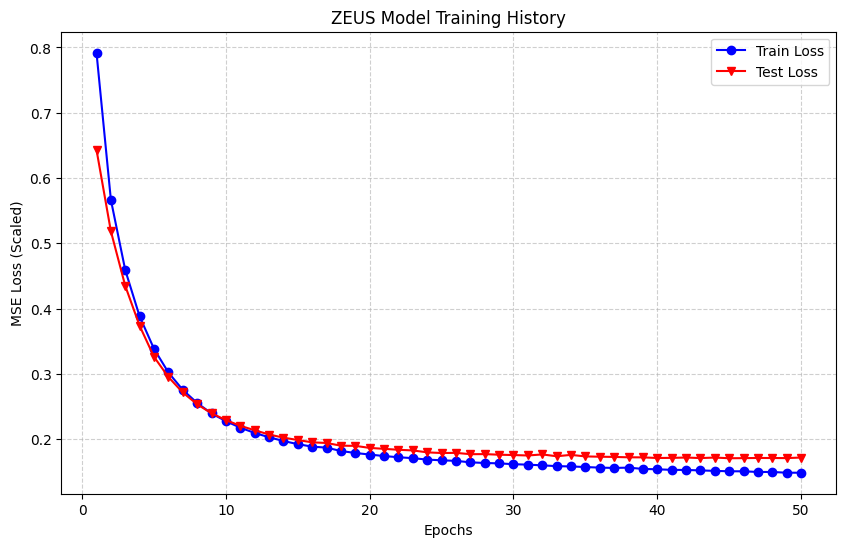

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# ---> CHANGE THIS LINE TO BE DYNAMIC <---
actual_epochs_run = len(train_losses)

# Use actual_epochs_run instead of the original 'epochs' variable
plt.plot(range(1, actual_epochs_run + 1), train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, actual_epochs_run + 1), test_losses, label='Test Loss', color='red', marker='v')

plt.title('ZEUS Model Training History')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig('training_performance.png')
plt.show()

In [8]:
torch.model_save_path = 'patch_mlp_zeus.pth'
torch.save(model.state_dict(), torch.model_save_path)

# CRITICAL: Save your mean and std dev so your prediction script can scale new data!
np.savez('scaling_params.npz', mean=train_dataset.mean, std=train_dataset.std)
print("Model and scaling parameters saved successfully!")

Model and scaling parameters saved successfully!


In [12]:
# 4. Export the model
dummy_input = torch.randn(1, 2000, 2).to(device)  # Adjust the shape to match your model's expected input
onnx_filename = "zeus_laser_tracker.onnx"

print(f"Exporting model to {onnx_filename}...")
torch.onnx.export(
    model,                      # The trained model instance
    dummy_input,                # A dummy input tensor with the correct shape
    onnx_filename,              # Output file name
    export_params=True,         # Store the trained parameter weights inside the file
    opset_version=17,           # Modern, highly stable ONNX operator version
    do_constant_folding=True,   # Optimizes the network math by pre-calculating constants
    input_names=['input_timeline'],   # Clean names for your input layer
    output_names=['predicted_xy'],    # Clean names for your output layer
    dynamic_axes={              # Allows you to use flexible batch sizes in production if needed
        'input_timeline': {0: 'batch_size'},
        'predicted_xy': {0: 'batch_size'}
    }
)

print("ONNX export complete and optimized!")

Exporting model to zeus_laser_tracker.onnx...
ONNX export complete and optimized!
